# Detección automática de armas en videovigilancia urbana
### Ajuste fino y evaluación de un detector YOLOv8 sobre el conjunto *Sohas weapon detection*

**Proyecto Aplicado I — Universidad Icesi**
Sara Maradiago · Prof. Yesid Ospitia

---

Este cuaderno documenta, paso a paso, el flujo completo de la implementación:
configuración del entorno, exploración de los datos, entrenamiento por
transferencia de aprendizaje, y **evaluación centrada en los falsos positivos
sobre objetos confundibles** (el error crítico para el despliegue real).

> **Cómo usar este cuaderno en la exposición**
> Ejecuta las celdas en orden con el kernel `Python (weapon-yolo)` (el `.venv`
> del proyecto). El entrenamiento completo tarda entre 1 y 3 h; por eso la celda
> de entrenamiento está desactivada por defecto (`ENTRENAR = False`) y el
> cuaderno reutiliza los pesos ya generados en `runs/`.

## 0. Objetivos y contexto

En Colombia, más del 91 % de los homicidios se cometen con armas de fuego o
cortopunzantes, y buena parte ocurre en la vía pública. La videovigilancia
existe pero está limitada por la fatiga del operador humano. Automatizar la
detección visual es la intervención más costo-efectiva.

Este trabajo entrena y evalúa un detector **YOLO de una etapa** —eficiente y
ejecutable en una GPU de consumo— y analiza su fiabilidad, con énfasis en
**distinguir un arma de un objeto inofensivo de tamaño similar** (teléfono,
billete, monedero, tarjeta), pues un falso positivo en la calle puede
desencadenar una intervención policial injustificada.

| # | Objetivo específico | Dónde se cumple en este cuaderno |
|---|---|---|
| 1 | Estructurar datos y preservar la partición oficial | §2 |
| 2 | Configurar/justificar YOLO en GPU de consumo | §1 y §3 |
| 3 | Entrenar y documentar hiperparámetros y hardware | §4 |
| 4 | Evaluar mAP, métricas por clase y **falsos positivos** | §5 y §6 |
| 5 | Costo computacional, brecha de dominio y **adaptación local** | §7 |

## 1. Configuración del entorno

Comprobamos las versiones y, sobre todo, que PyTorch reconozca la GPU. La
RTX 5070 es arquitectura *Blackwell* (`sm_120`), muy reciente, por lo que
requiere una compilación de PyTorch con CUDA 12.8; de lo contrario fallaría con
un error de *"no kernel image available"*.

In [1]:
from pathlib import Path
import torch, ultralytics

def find_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "src" / "sohas.yaml").exists():
            return p
    raise FileNotFoundError("No encuentro la raíz del proyecto (src/sohas.yaml)")

ROOT = find_root()
print("Raíz del proyecto:", ROOT)
print("PyTorch     :", torch.__version__)
print("Ultralytics :", ultralytics.__version__)
print("CUDA        :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
    print("Capability  : sm_%d%d" % torch.cuda.get_device_capability(0))
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print("VRAM        : %.1f GB" % vram)

DEVICE = 0 if torch.cuda.is_available() else "cpu"

Raíz del proyecto: /home/sara/Documents/other/weapon_detection
PyTorch     : 2.11.0+cu128
Ultralytics : 8.4.164
CUDA        : True
GPU         : NVIDIA GeForce RTX 5070
Capability  : sm_120
VRAM        : 11.5 GB


## 2. El conjunto de datos *Sohas weapon detection*

Publicado por el instituto DaSCI. Reúne en las mismas imágenes las **2 clases de
armas** de interés junto con **4 clases de objetos confundibles**. Esa
coexistencia es lo que permite medir el error operativo crítico.

**Formato YOLO.** Cada imagen tiene un `.txt` con el mismo nombre; una línea por
objeto: `clase  x_centro  y_centro  ancho  alto` (coordenadas normalizadas 0–1).
El dataset ya viene en este formato y con la **partición oficial** train/test,
así que no fue necesario convertir desde Pascal VOC.

La configuración que Ultralytics necesita vive en `src/sohas.yaml`:

In [2]:
import yaml

with open(ROOT / "src" / "sohas.yaml") as f:
    cfg = yaml.safe_load(f)

DATA_YAML = ROOT / "src" / "sohas.yaml"
DATA_ROOT = Path(cfg["path"])
NAMES = cfg["names"]
print("Raíz de datos:", DATA_ROOT)
print("Clases:", NAMES)

Raíz de datos: /home/sara/Documents/other/weapon_detection/OD-WeaponDetection-master/Weapons and similar handled objects/Sohas_weapon-Detection-YOLOv5/obj_train_data
Clases: {0: 'pistol', 1: 'smartphone', 2: 'knife', 3: 'monedero', 4: 'billete', 5: 'tarjeta'}


### 2.1 Distribución de clases y tamaño de las particiones

Contamos las instancias (objetos anotados) por clase en cada partición. Sirve
para dejar constancia del tamaño del problema y de un **desbalance** natural
(hay muchos más `knife`/`pistol` que `tarjeta`), que conviene tener presente al
interpretar las métricas.

train : 5002 imágenes, 5002 objetos
test  : 857 imágenes, 857 objetos


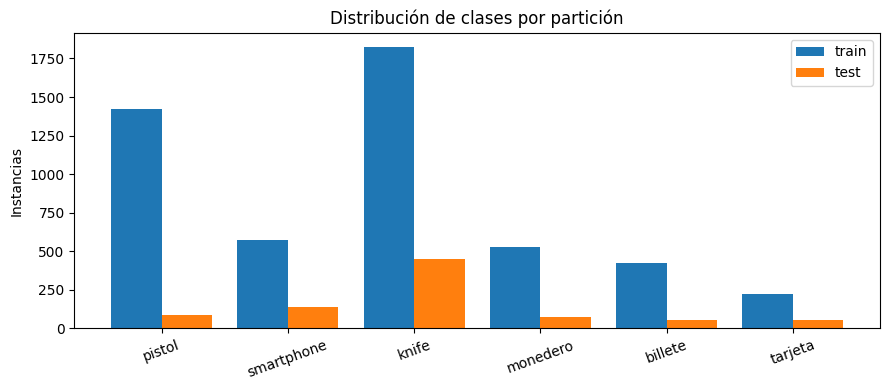

In [3]:
import matplotlib.pyplot as plt
from collections import Counter

def contar_instancias(split):
    labels_dir = DATA_ROOT / "labels" / split
    counts = Counter()
    n_img = 0
    for txt in labels_dir.glob("*.txt"):
        n_img += 1
        for line in txt.read_text().splitlines():
            line = line.strip()
            if line:
                counts[int(line.split()[0])] += 1
    return n_img, counts

clases = [NAMES[i] for i in sorted(NAMES)]
resumen = {}
for split in ["train", "test"]:
    n_img, counts = contar_instancias(split)
    resumen[split] = [counts.get(i, 0) for i in sorted(NAMES)]
    print(f"{split:<6}: {n_img} imágenes, {sum(counts.values())} objetos")

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(clases))
ax.bar([i - 0.2 for i in x], resumen["train"], width=0.4, label="train")
ax.bar([i + 0.2 for i in x], resumen["test"],  width=0.4, label="test")
ax.set_xticks(list(x)); ax.set_xticklabels(clases, rotation=20)
ax.set_ylabel("Instancias"); ax.set_title("Distribución de clases por partición")
ax.legend(); plt.tight_layout(); plt.show()

### 2.2 Una imagen de ejemplo con sus anotaciones

Dibujamos las cajas reales sobre una imagen para verificar visualmente que las
etiquetas están bien y para ilustrar la tarea en la exposición.

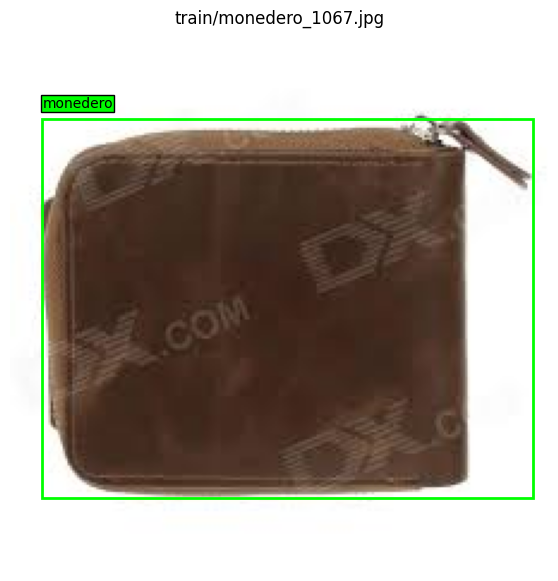

In [4]:
from PIL import Image
import matplotlib.patches as patches
import random

def mostrar_con_cajas(split="train", nombre=None):
    img_dir = DATA_ROOT / "images" / split
    lbl_dir = DATA_ROOT / "labels" / split
    if nombre is None:
        nombre = random.choice([p.stem for p in lbl_dir.glob("*.txt")])
    img_path = next(img_dir.glob(nombre + ".*"))
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    fig, ax = plt.subplots(figsize=(7, 7)); ax.imshow(img)
    for line in (lbl_dir / (nombre + ".txt")).read_text().splitlines():
        c, xc, yc, w, h = line.split()
        c = int(c); xc, yc, w, h = float(xc)*W, float(yc)*H, float(w)*W, float(h)*H
        ax.add_patch(patches.Rectangle((xc-w/2, yc-h/2), w, h,
                     fill=False, edgecolor="lime", linewidth=2))
        ax.text(xc-w/2, yc-h/2-5, NAMES[c], color="black",
                bbox=dict(facecolor="lime", pad=1), fontsize=10)
    ax.set_title(f"{split}/{img_path.name}"); ax.axis("off"); plt.show()

mostrar_con_cajas("train")

## 3. El modelo y la transferencia de aprendizaje

YOLO es un detector de **una etapa**: en una sola pasada predice, a la vez, la
posición y la clase de cada objeto. Por eso es rápido y cabe en una GPU de
consumo, a diferencia de los detectores de dos etapas (Faster/Mask R-CNN) o los
basados en atención (DETR), de mayor costo computacional.

No entrenamos desde cero: partimos de pesos **preentrenados en COCO** (80 clases
generales) y re-especializamos la red en nuestras 6 clases. La red ya sabe
extraer bordes, texturas y formas; solo le enseñamos las categorías nuevas. Eso
es lo que permite obtener buenos resultados con ~5 000 imágenes.

Elegimos **YOLOv8s** ("small") como punto dulce entre precisión y eficiencia
para 12 GB de VRAM.

## 4. Entrenamiento

Los hiperparámetros son la parte que se documenta para la reproducibilidad
(objetivo 3):

| Parámetro | Valor | Razón |
|---|---|---|
| modelo base | `yolov8s.pt` | balance precisión/velocidad en GPU de consumo |
| épocas | 100 (parada temprana) | corta sola si deja de mejorar → evita sobreajuste |
| `imgsz` | 640 | resolución estándar de YOLO |
| `batch` | 16 | limitado por la VRAM (bajar a 8 si falta memoria) |
| aumento de datos | por defecto | volteo, recorte, brillo/color → robustez a iluminación |

> La celda siguiente **no entrena por defecto** (`ENTRENAR = False`) para no
> disparar un proceso de horas durante la exposición. Ponla en `True` para
> (re)entrenar. Con `False`, el cuaderno usa los pesos ya generados en `runs/`.

In [5]:
from ultralytics import YOLO

ENTRENAR    = False          # ← True para (re)entrenar de verdad
MODELO_BASE = "yolov8s.pt"
EPOCHS      = 100
RUN_NAME    = "yolov8s_sohas"

if ENTRENAR:
    model = YOLO(MODELO_BASE)
    resultados = model.train(
        data=str(DATA_YAML), epochs=EPOCHS, imgsz=640, batch=16,
        device=DEVICE, project=str(ROOT / "runs"), name=RUN_NAME,
        patience=20, seed=0, plots=True, exist_ok=True,
    )
    print("Entrenamiento terminado. Resultados en:", resultados.save_dir)
else:
    print("ENTRENAR=False → se usarán pesos existentes (ver celda siguiente).")

ENTRENAR=False → se usarán pesos existentes (ver celda siguiente).


Seleccionamos los pesos a evaluar. Se prefiere el entrenamiento completo
(`yolov8s_sohas`); si aún no existe, se recurre a la prueba de humo (`smoke`)
para que el cuaderno sea ejecutable de inmediato (sus métricas serán bajas por
ser de 1 época).

In [6]:
def elegir_pesos():
    for name in [RUN_NAME, "smoke"]:
        w = ROOT / "runs" / name / "weights" / "best.pt"
        if w.exists():
            if name == "smoke":
                print("⚠️  Usando pesos de la PRUEBA DE HUMO (1 época). "
                      "Entrena el modelo completo para resultados reales.")
            return w
    raise FileNotFoundError("No hay pesos. Entrena primero (ENTRENAR=True).")

WEIGHTS = elegir_pesos()
print("Pesos seleccionados:", WEIGHTS)

Pesos seleccionados: /home/sara/Documents/other/weapon_detection/runs/yolov8s_sohas/weights/best.pt


### 4.1 Curvas de entrenamiento

Si el entrenamiento completo existe, mostramos las curvas de pérdida y métricas
que Ultralytics genera automáticamente.

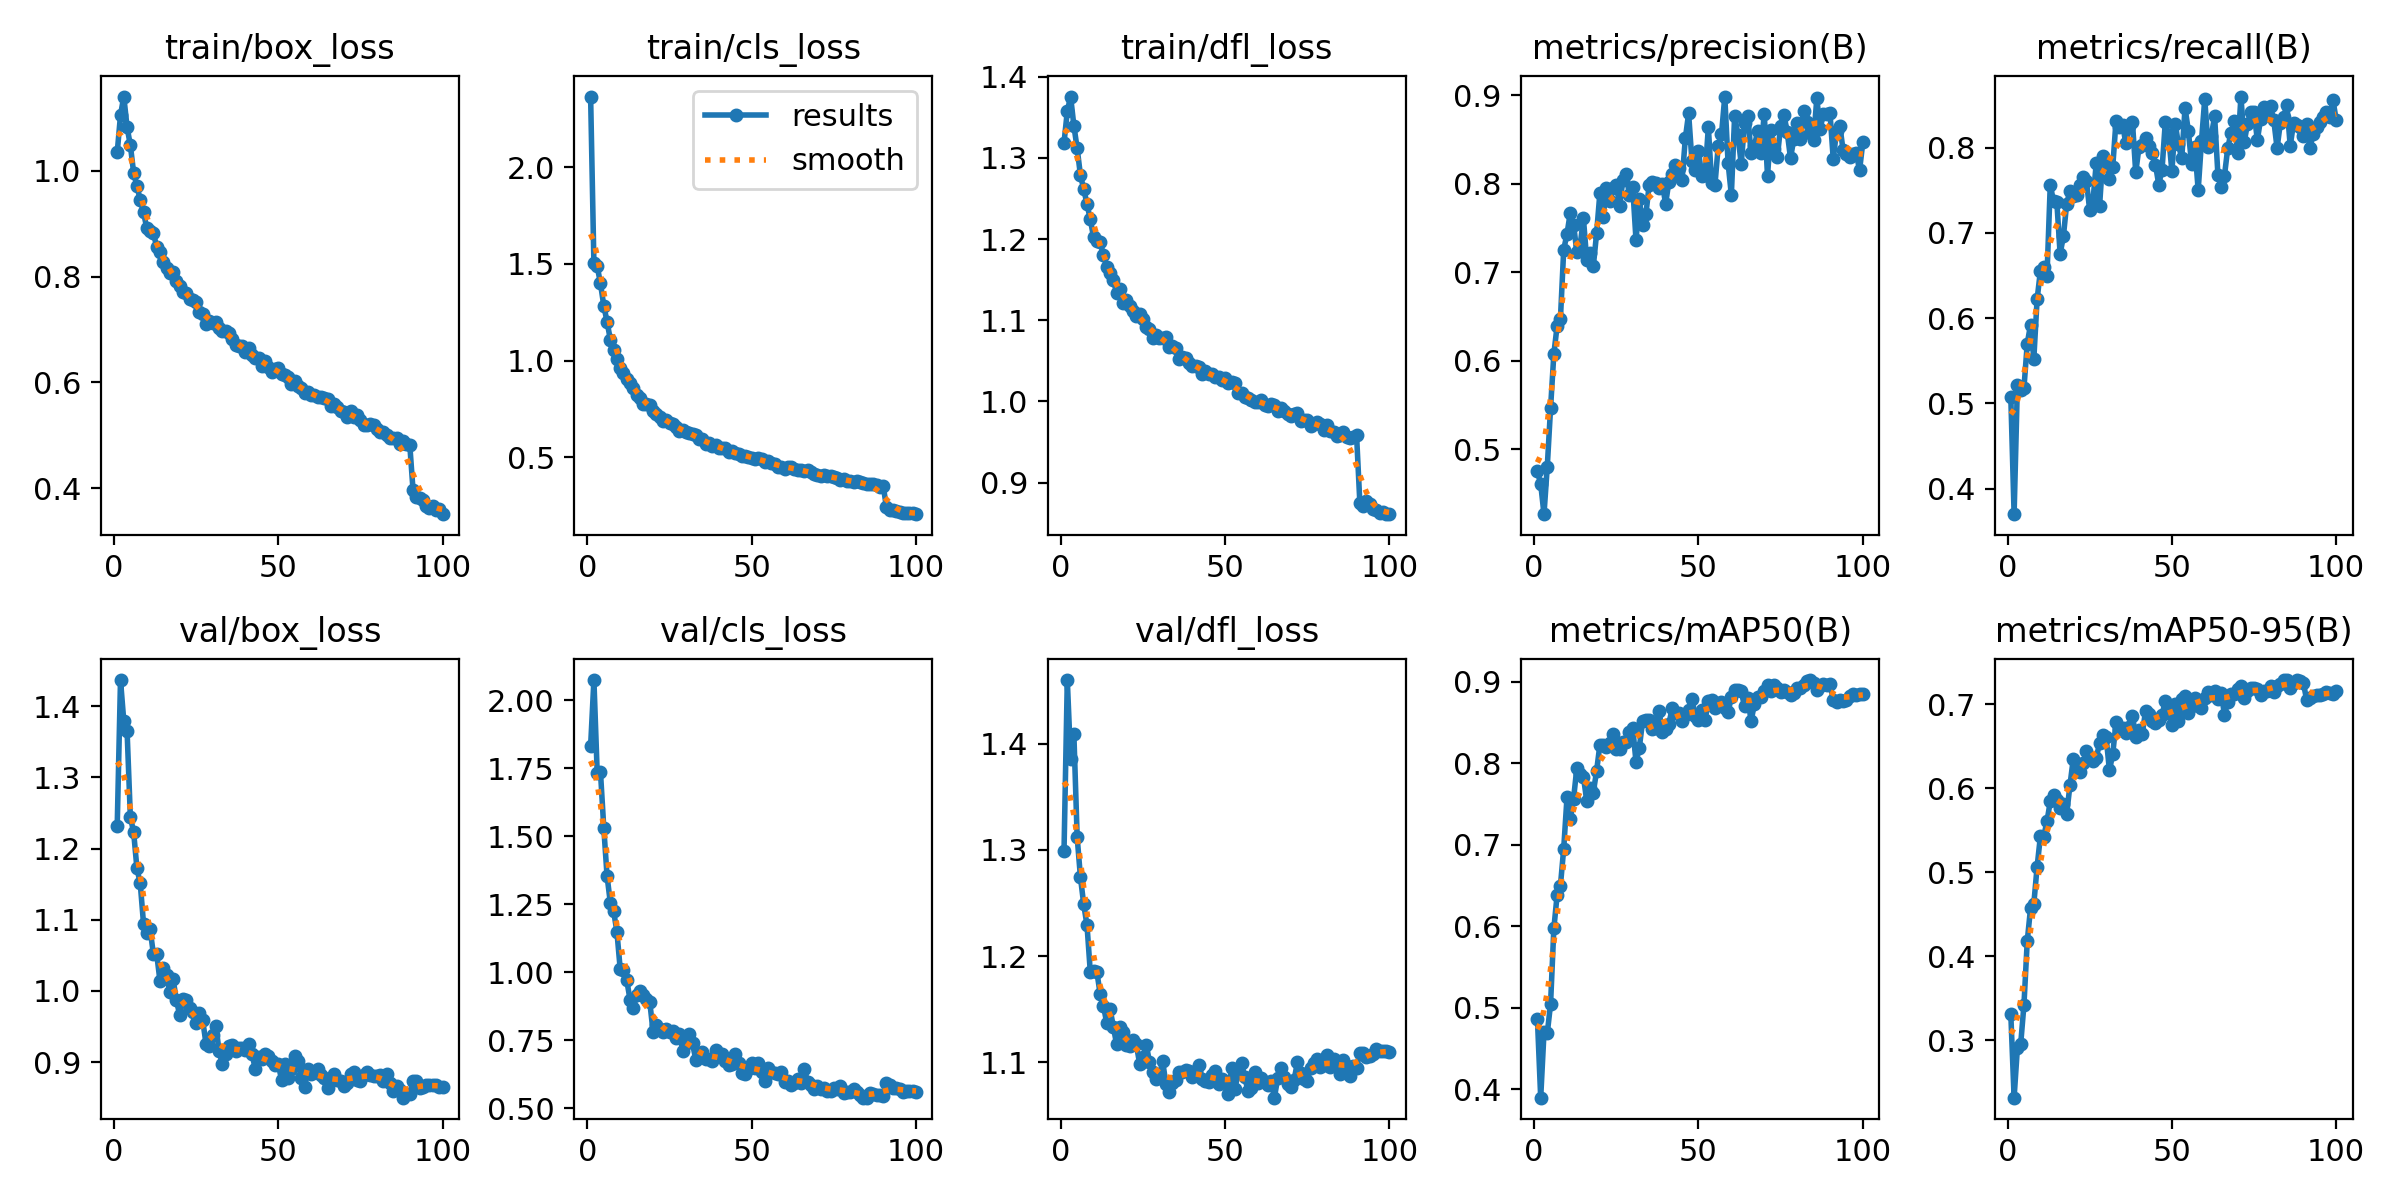

In [7]:
from IPython.display import Image as IPImage, display

run_dir = WEIGHTS.parent.parent
results_png = run_dir / "results.png"
if results_png.exists():
    display(IPImage(filename=str(results_png)))
else:
    print("No hay results.png en", run_dir)

## 5. Evaluación sobre la partición de prueba

Corremos el modelo sobre las 857 imágenes de test que **nunca vio**. Reportamos:

- **mAP@0.5** y **mAP@0.5:0.95** — desempeño global (métrica estándar).
- **Precisión y recall por clase** — que `pistol`/`knife` tengan buen recall (no
  se escapan armas) y buena precisión (no dispara falsas alarmas).

In [8]:
model = YOLO(str(WEIGHTS))
metrics = model.val(data=str(DATA_YAML), imgsz=640, device=DEVICE,
                    project=str(ROOT / "runs"), name="eval", exist_ok=True, plots=True)

print("\n===== Métricas globales =====")
print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"Precisión    : {metrics.box.mp:.4f}")
print(f"Recall       : {metrics.box.mr:.4f}")

print("\n===== Por clase =====")
print(f"{'clase':<12}{'P':>8}{'R':>8}{'mAP50':>8}{'mAP50-95':>10}")
for i, c in enumerate(metrics.box.ap_class_index):
    print(f"{model.names[c]:<12}{metrics.box.p[i]:>8.3f}{metrics.box.r[i]:>8.3f}"
          f"{metrics.box.ap50[i]:>8.3f}{metrics.box.ap[i]:>10.3f}")

Ultralytics 8.4.164 🚀 Python-3.10.12 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070, 11765MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9954.1±2997.8 MB/s, size: 167.9 KB)
val: Scanning /home/sara/Documents/other/weapon_detection/OD-WeaponDetection-master/Weapons and similar handled objects/Sohas_weapon-Detection-YOLOv5/obj_train_data/labels/test.cache... 857 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 857/857 299.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 20.6it/s 2.6s0.1s
                   all        857        857      0.879      0.825      0.896      0.728
                pistol         85         85      0.927      0.892       0.96      0.791
            smartphone        140        140      0.944      0.835      0.951      0.803
                 knife        452        452      0.974      0.945  

### 5.1 Matriz de confusión — el análisis de falsos positivos

**Esta es la parte central del proyecto.** La matriz de confusión muestra con
qué confunde el modelo cada categoría. La pregunta crítica es: *¿cuántas veces
predice `pistol`/`knife` cuando en realidad había un objeto inofensivo
(smartphone, monedero, billete, tarjeta) o solo fondo?* Esas celdas son los
falsos positivos que, en la calle, provocan intervenciones injustificadas.

- **Filas = predicción, columnas = realidad** (versión normalizada por columna).
- Mira la fila `pistol` y la fila `knife`: idealmente, fuera de su diagonal y de
  la columna `background`, deben estar casi vacías.

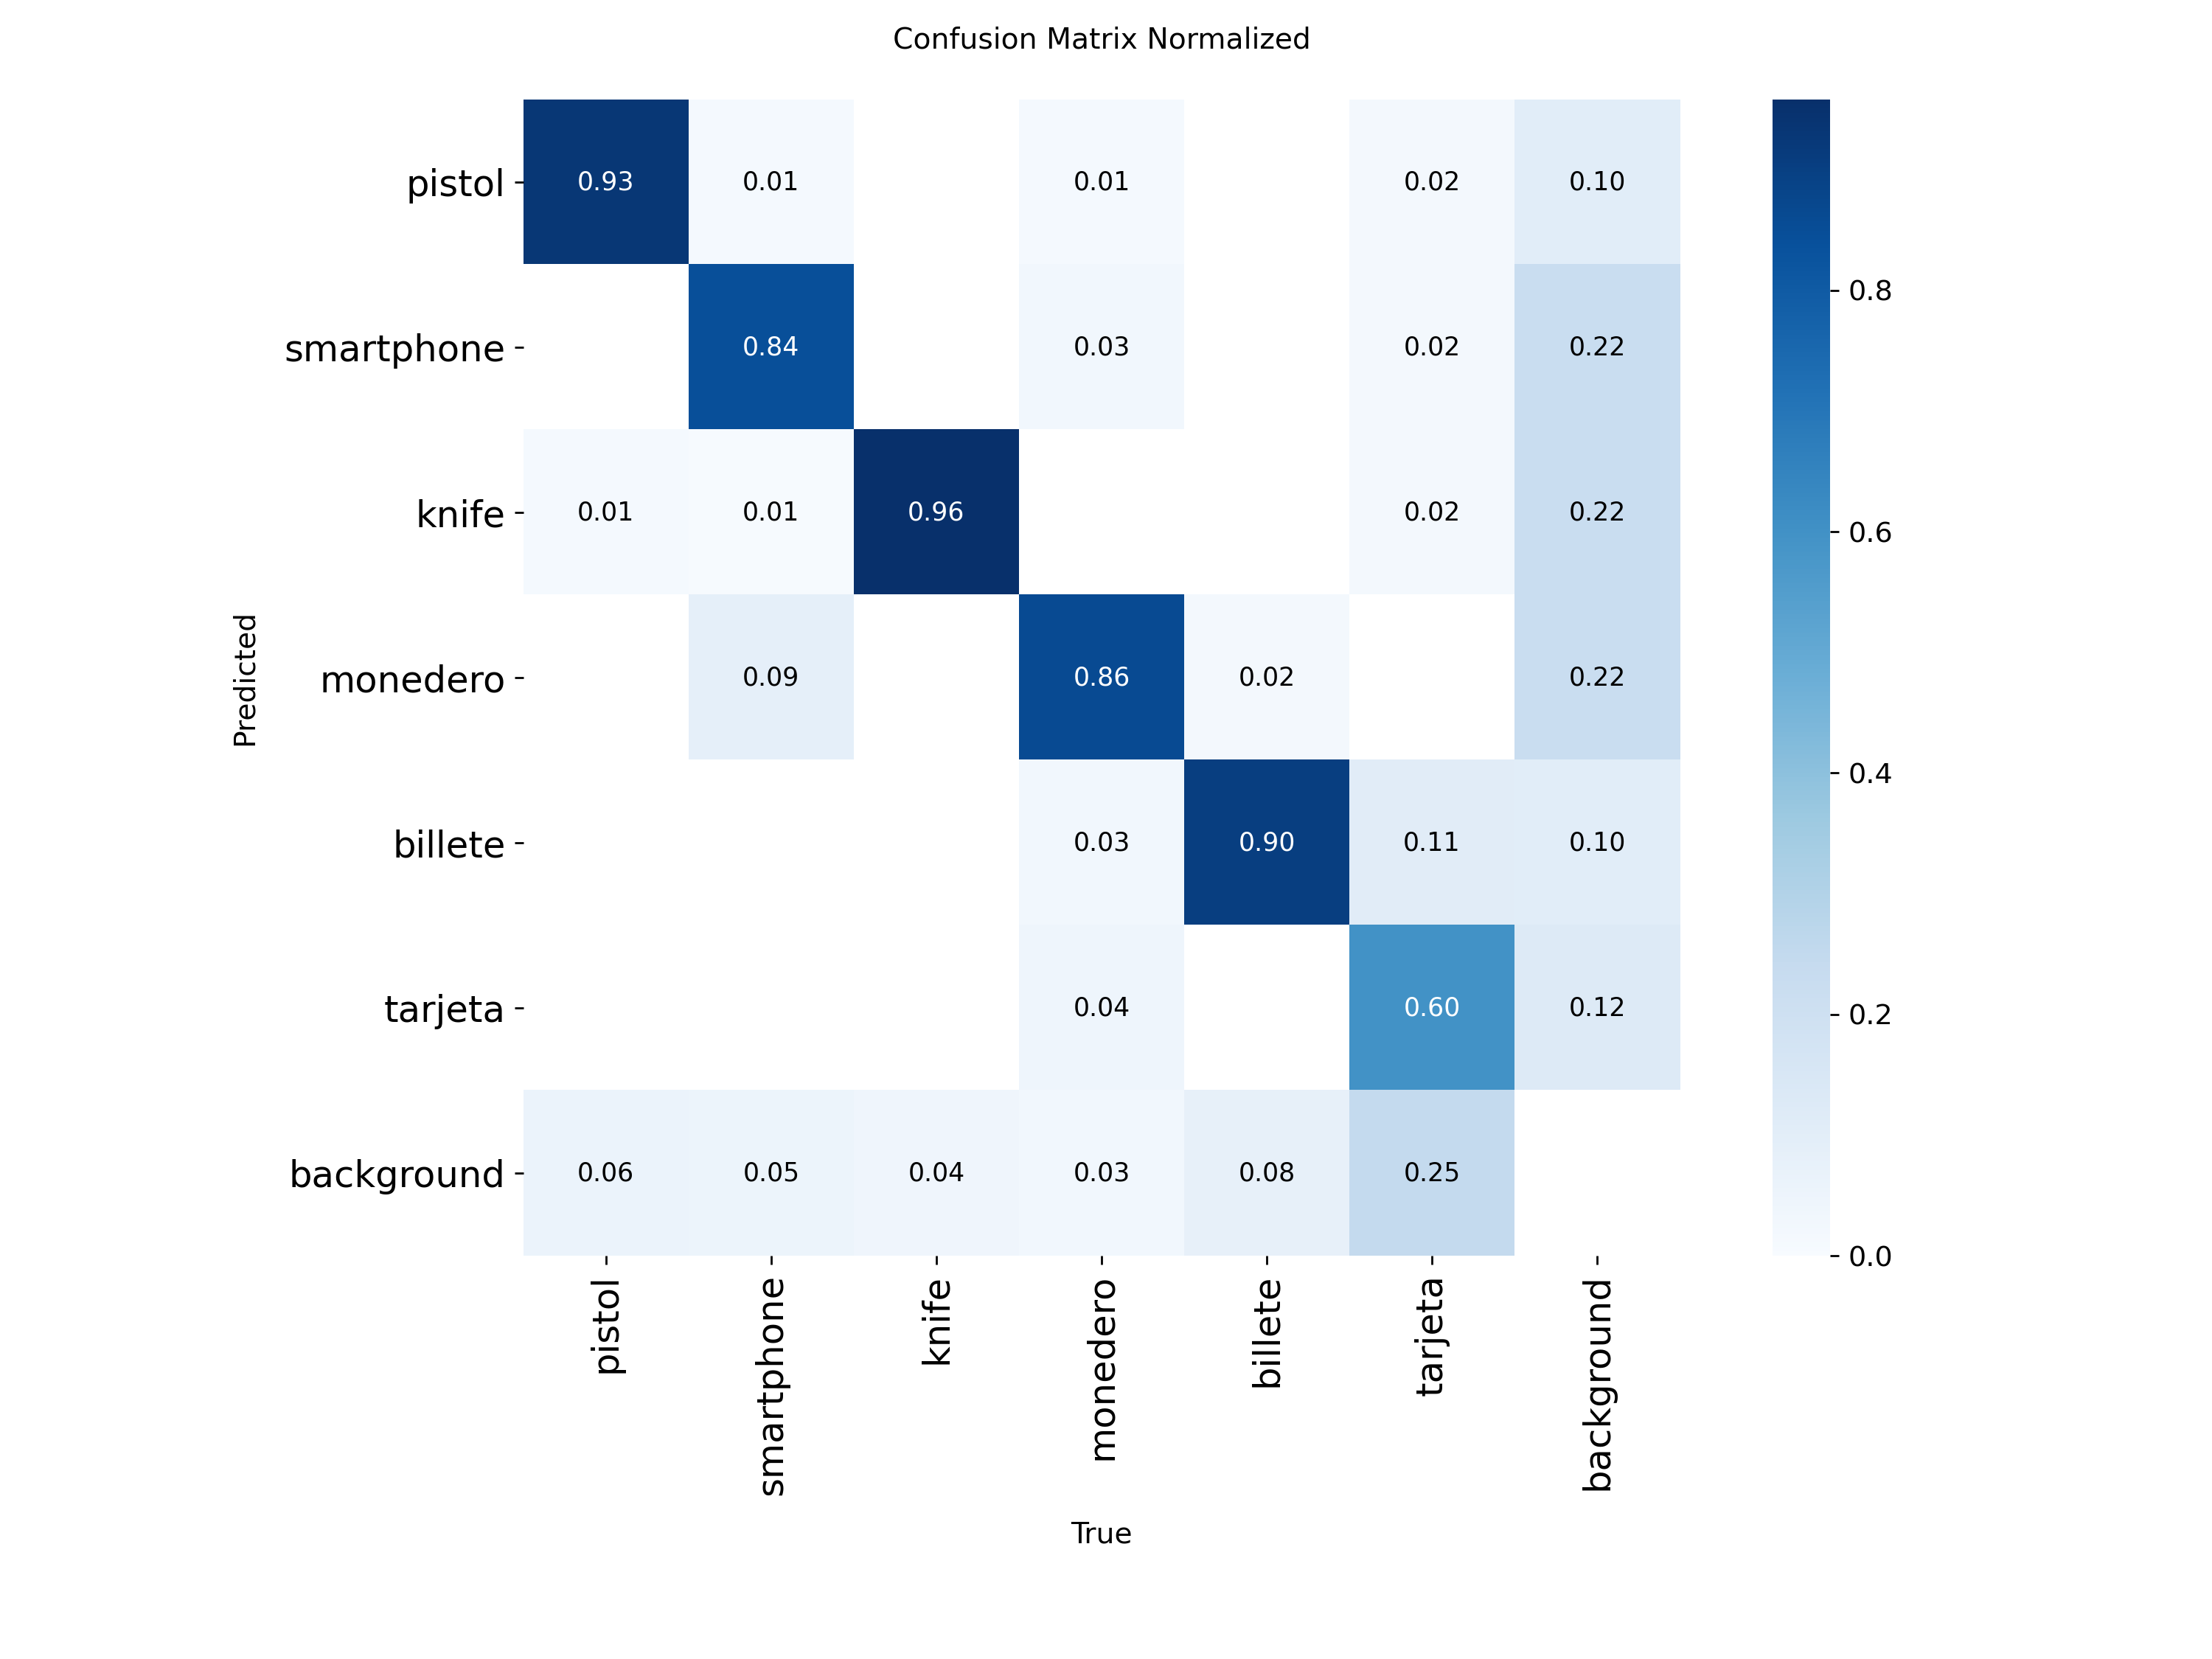

In [9]:
eval_dir = ROOT / "runs" / "eval"
cm = eval_dir / "confusion_matrix_normalized.png"
if cm.exists():
    display(IPImage(filename=str(cm)))
else:
    print("No se encontró la matriz en", eval_dir)

## 6. Inferencia cualitativa

Más allá de los números, mostramos detecciones sobre imágenes de prueba. Es lo
más ilustrativo para la exposición: se ve el modelo funcionando y se pueden
señalar aciertos y errores concretos sobre objetos confundibles.

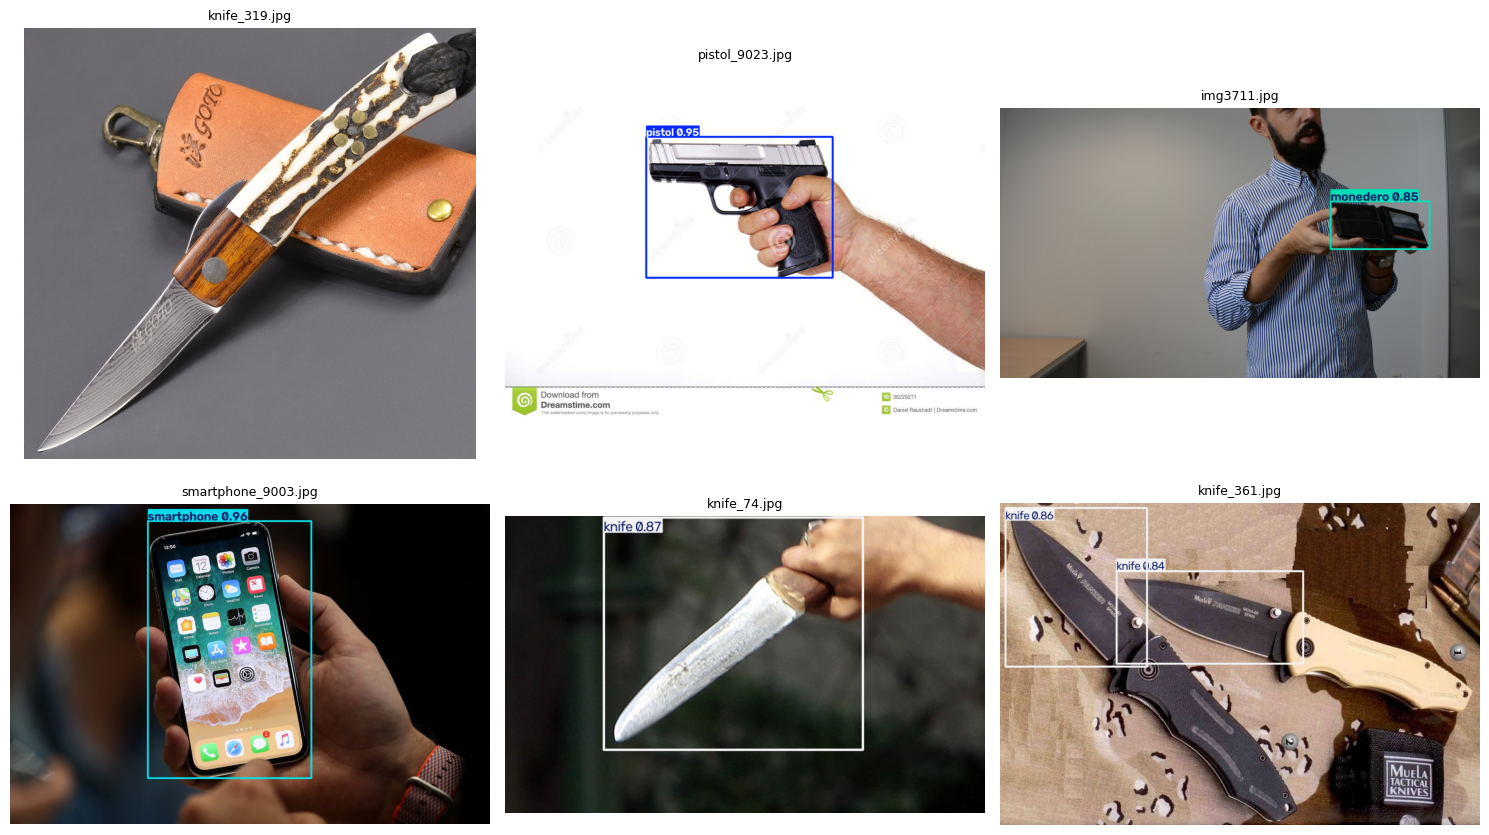

In [10]:
import random

test_imgs = list((DATA_ROOT / "images" / "test").glob("*.*"))
muestra = random.sample(test_imgs, 6)

preds = model.predict(source=[str(p) for p in muestra], imgsz=640,
                      conf=0.25, device=DEVICE, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, r in zip(axes.ravel(), preds):
    ax.imshow(r.plot()[:, :, ::-1])   # BGR->RGB
    ax.set_title(Path(r.path).name, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Condiciones reales y adaptación local

Un buen mAP en *Sohas* no garantiza que el detector funcione frente a una
cámara real. Para comprobarlo, se desplegó sobre dos cámaras de consumo en un
entorno doméstico (una IP TP-Link Tapo y una cámara web USB) con los módulos
`src/camera.py`, `src/stream_infer.py` y `src/capture_samples.py`.

Hallazgos de la evaluación exploratoria (116 capturas con la Tapo):

- **La escala es la causa principal de fallo.** Las cámaras son gran angular y el
  cuchillo ocupa una fracción mínima del cuadro; a 640 píxeles apenas se ve.
- **La luz y el desenfoque no explicaron los fallos.**
- **El modelo aprendió atajos:** "mano que empuña un objeto oscuro" → *pistol*
  (un teléfono levantado salió como pistola con 0,90), y un estampado o una
  franja decorativa → cuchillo o billete.

### 7.1 Costo de subir la resolución

Medimos la latencia por cuadro a cada resolución. Para que sea comparable con la
cámara Tapo, la imagen se lleva a 2304×1296 píxeles (usamos una imagen de
*Sohas*, así la medición es reproducible sin datos privados).

In [11]:
import time
import cv2

base_model = YOLO(str(WEIGHTS))
img = cv2.imread(str(next((DATA_ROOT / "images" / "test").glob("*.*"))))
frame = cv2.resize(img, (2304, 1296))

for sz in (640, 960, 1280):
    for _ in range(5):                      # calentamiento
        base_model.predict(frame, imgsz=sz, device=DEVICE, verbose=False)
    t0 = time.time(); n = 50
    for _ in range(n):
        base_model.predict(frame, imgsz=sz, device=DEVICE, verbose=False)
    dt = (time.time() - t0) / n
    print(f"imgsz {sz:4d}: {dt * 1000:5.1f} ms/cuadro -> {1 / dt:5.0f} cuadros/s (la Tapo entrega 15)")

imgsz  640:   3.4 ms/cuadro ->   296 cuadros/s (la Tapo entrega 15)
imgsz  960:   4.7 ms/cuadro ->   212 cuadros/s (la Tapo entrega 15)
imgsz 1280:   6.9 ms/cuadro ->   146 cuadros/s (la Tapo entrega 15)


Efecto de la resolución sobre las 50 capturas con cuchillo y las 19 capturas
manuales sin arma de la Tapo (modelo entrenado en *Sohas*, umbral 0,35):

| Resolución | Cuchillo detectado | Cuchillo como pistola | Falsas alarmas |
|---|---|---|---|
| 640  | 21/50 (42 %) | 11/50 | 6/19 |
| 960  | 26/50 (52 %) | 11/50 | 3/19 |
| **1280** | **33/50 (66 %)** | **6/50** | **3/19** |

A 1280 píxeles sigue siendo tiempo real, así que es la resolución que se usa en
el despliegue. Las capturas no están en el repositorio porque contienen
imágenes de personas.

### 7.2 Ajuste fino con imágenes locales

Para corregir los atajos se grabaron 230 imágenes con la cámara web fija: tres
sesiones de entrenamiento (cuchillos en varias posturas, objetos cotidianos en
esas mismas posturas, escenas mixtas) y **una sesión solo de prueba**, grabada al
final y con otra ropa. Las cajas se anotaron con `src/label_captures.py`
(el modelo propone y una persona corrige), el conjunto se construyó con
`src/build_local_dataset.py` (separación estricta por sesión) y el modelo se
ajustó partiendo del entrenado en *Sohas*, mezclando ambos conjuntos para que
no olvidara lo aprendido.

La celda siguiente compara el modelo original con el ajustado sobre la sesión de
prueba (umbral de alarma 0,35, fijado antes de evaluar) y vuelve a medir *Sohas*.

In [12]:
import subprocess, sys

TEST_LOCAL = ROOT / "datasets" / "local" / "test.yaml"
FT_WEIGHTS = ROOT / "runs" / "ft_local" / "weights" / "best.pt"

if TEST_LOCAL.exists() and FT_WEIGHTS.exists():
    salida = subprocess.run(
        [sys.executable, str(ROOT / "src" / "eval_local.py"),
         "--weights", str(WEIGHTS), str(FT_WEIGHTS), "--sohas"],
        capture_output=True, text=True, cwd=ROOT,
    ).stdout
    print(salida[salida.find("Test local"):])
else:
    print("Los datos locales son privados y no están en el repositorio. Resultados obtenidos:\n")
    print("modelo     mAP50 local  alarma con arma  clase correcta  falsas alarmas  mAP50 Sohas")
    print("original       0.481    11/13 (84.6%)    9/13 (69.2%)   7/47 (14.9%)        0.863")
    print("ajustado       0.756    12/13 (92.3%)   12/13 (92.3%)   3/47 ( 6.4%)        0.896")

Test local (/home/sara/Documents/other/weapon_detection/datasets/local), umbral de alarma 0.35, imgsz 1280

modelo             mAP50 local  alarma con arma   clase correcta    alarma sin arma     mAP50 Sohas
yolov8s_sohas            0.481   84.6% (11/13)     69.2% (9/13)      14.9% (7/47)             0.863
ft_local                 0.756   92.3% (12/13)     92.3% (12/13)      6.4% (3/47)             0.896

mAP50 por clase (test local):
modelo                 billete       knife    monedero  smartphone
yolov8s_sohas            0.003       0.628       0.300       0.995
ft_local                 0.755       0.764       0.629       0.875

Matrices de confusión en runs/eval_local_<modelo>/



**Lectura:** el ajuste fino corrigió el atajo principal (6 de las 7 falsas
alarmas del modelo original eran una billetera tomada por pistola) y dejó la
alarma con la clase correcta en 12 de 13 imágenes con arma, sin olvidar *Sohas*.
Empeoró la clase *smartphone*, que tenía solo 5 ejemplos locales.

**Salvedad:** la muestra es pequeña y es una sola habitación, persona y cámara:
mide la adaptación a ese entorno, no la generalización a cualquier cámara.

## 8. Conclusiones y trabajo futuro

- Se entrenó un detector **YOLOv8s** sobre *Sohas weapon detection* en una
  **GPU de consumo (RTX 5070, 12 GB)**: mAP@0,5 de **0,896**, con confusión entre
  armas y objetos inofensivos muy baja.
- **Brecha de dominio:** frente a cámaras reales el desempeño cayó y aparecieron
  falsas alarmas que *Sohas* no anticipaba (billetera o teléfono → pistola).
  Un buen mAP en el conjunto de referencia no basta para juzgar el despliegue.
- **Dos medidas baratas la mitigaron:** inferir a 1280 píxeles (6 ms/cuadro) y un
  ajuste fino con 230 imágenes locales (< 1 h): alarma correcta en 12/13 imágenes
  con arma y falsas alarmas de 7/47 a 3/47, sin olvidar *Sohas*.
- **Limitaciones:** muestra pequeña, un solo entorno, sin armas de fuego reales.
- **Trabajo futuro:** simular la calidad de la videovigilancia, confirmación
  temporal de alarmas, examinar de cerca las regiones dudosas (zoom o pose),
  visión activa con cámaras motorizadas y datos más diversos. Las señales de
  comportamiento, con cautela: pueden discriminar a personas que se mueven de
  forma distinta.